**DL Assignment 7**

Name: Kuber Kishore <br>
Class: TY CSAI - A <br>
Batch: 3 <br>
Roll No.: 57 <br>
Date: 12-03-2026 <br>


---


**Problem Statement:** <br>
Convolutional neural network (CNN): Use any dataset of plant disease and design a plant disease detection system using CNN.

---



# Import libraries

In [ ]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

# Upload dataset ZIP


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving plantdisease.zip to plantdisease.zip


# Extract dataset

In [ ]:
zip_path = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("data")

# Parameters

In [ ]:
data_dir = "data/PlantVillage"
img_size = 128
batch_size = 32

# Data preprocessing

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_data = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    subset='validation'
)

Found 16516 images belonging to 15 classes.
Found 4122 images belonging to 15 classes.


# Build CNN model

In [ ]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(img_size, img_size, 3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(train_data.num_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Compile model

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,306,575 (12.61 MB)

 Trainable params: 3,306,575 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

# Train model

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 595s 1s/step - accuracy: 0.4098 - loss: 1.8161 - val_accuracy: 0.6737 - val_loss: 0.9983
Epoch 2/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 593s 1s/step - accuracy: 0.6101 - loss: 1.1758 - val_accuracy: 0.7615 - val_loss: 0.7172
Epoch 3/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 594s 1s/step - accuracy: 0.6656 - loss: 0.9873 - val_accuracy: 0.7863 - val_loss: 0.6653
Epoch 4/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 628s 1s/step - accuracy: 0.6982 - loss: 0.8756 - val_accuracy: 0.8227 - val_loss: 0.5480
Epoch 5/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 581s 1s/step - accuracy: 0.7308 - loss: 0.7809 - val_accuracy: 0.8083 - val_loss: 0.5746
Epoch 6/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 583s 1s/step - accuracy: 0.7660 - loss: 0.6904 - val_accuracy: 0.8549 - val_loss: 0.4235
Epoch 7/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 586s 1s/step - accuracy: 0.7864 - loss: 0.6218 - val_accuracy: 0.8721 - val_loss: 0.3831
Epoch 8/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 589s 1s/step - accuracy: 0.8036 - loss: 0.5718 - val_accu

# Plot results

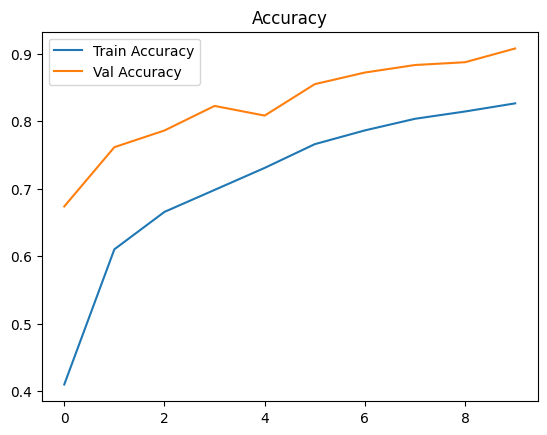

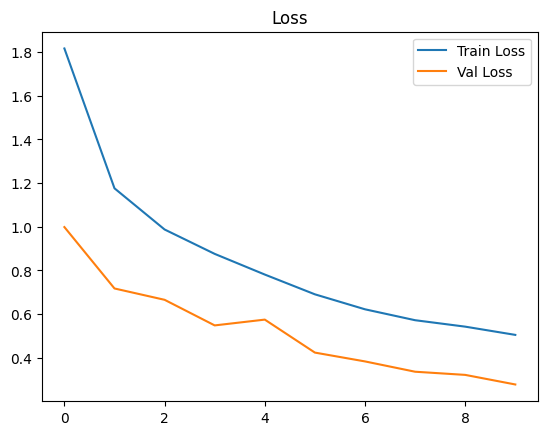

In [ ]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Accuracy")
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss")
plt.show()

# Test on image

In [23]:
from google.colab import files
uploaded = files.upload()

Saving test.jpg to test (1).jpg


In [24]:
from tensorflow.keras.preprocessing import image

img_path = list(uploaded.keys())[0]

img = image.load_img(img_path, target_size=(img_size, img_size))
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)
class_idx = np.argmax(prediction)

print("Predicted class:", list(train_data.class_indices.keys())[class_idx])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Predicted class: Tomato_Late_blight


# Save model

In [ ]:
model.save("plant_disease_model.h5")